# 01 · Lectura y Discovery
**Proyecto:** Predicción de fumadores (`smoking`)  
**Objetivo:** Cargar el dataset, entender su estructura, detectar problemas iniciales y dejar los datos listos para el EDA.

Para entender mejor el problema hay que saber el significado de cada columna


#### Datos personales

| Variable | Descripción |
|---|---|
| `gender` | Sexo biológico (F = femenino, M = masculino) |
| `age` | Edad en años |
| `height_cm` | Talla en centímetros |
| `weight_kg` | Peso en kilogramos |
| `waist_cm` | Circunferencia de cintura en cm. Indicador de grasa abdominal |


#### Sentidos

| Variable | Descripción |
|---|---|
| `eyesight_left` | Agudeza visual ojo izquierdo (1.0 = visión perfecta) |
| `eyesight_right` | Agudeza visual ojo derecho (1.0 = visión perfecta) |
| `hearing_left` | Audición oído izquierdo (1 = normal, 2 = con pérdida) |
| `hearing_right` | Audición oído derecho (1 = normal, 2 = con pérdida) |


#### Presión arterial

| Variable | Descripción |
|---|---|
| `systolic` | Presión sistólica — el número "alto" (ej. **120**/80) |
| `relaxation` | Presión diastólica — el número "bajo" (ej. 120/**80**) |



#### Análisis de sangre

| Variable | Descripción |
|---|---|
| `fasting_blood_sugar` | Glucosa en sangre en ayunas. Valores altos indican riesgo de diabetes |
| `cholesterol` | Colesterol total en sangre |
| `triglyceride` | Triglicéridos — otro tipo de grasa en sangre |
| `hdl` | Colesterol "bueno" (High Density Lipoprotein). Más alto = mejor |
| `ldl` | Colesterol "malo" (Low Density Lipoprotein). Más alto = peor |
| `hemoglobin` | Proteína que transporta oxígeno en los glóbulos rojos |



#### Función renal

| Variable | Descripción |
|---|---|
| `urine_protein` | Proteína en orina. Normalmente ausente; su presencia indica daño renal |
| `serum_creatinine` | Producto de desecho filtrado por el riñón. Valores altos = función renal comprometida |



#### Función hepática

| Variable | Descripción |
|---|---|
| `ast` | Enzima AST/GOT. Sube ante daño hepático o muscular |
| `alt` | Enzima ALT/GPT. Más específica del hígado que la AST |
| `gtp` | Enzima GGT. Muy sensible al alcohol y enfermedades del hígado |



#### Salud bucal

| Variable | Descripción |
|---|---|
| `oral` | Higiene oral (Y = sí, N = no) |
| `dental_caries` | Presencia de caries (0 = no, 1 = sí) |
| `tartar` | Presencia de sarro (Y = sí, N = no) |


#### Variable target

| Variable | Descripción |
|---|---|
| `smoking` | **Variable a predecir.** Si la persona es fumadora (1 = fuma, 0 = no fuma) |




### Analisis de deducciones

1. Variables de Alta Prioridad (Las "Imprescindibles")


- hemoglobin (Hemoglobina): Es el predictor numérico más fuerte. El tabaco eleva artificialmente los glóbulos rojos para compensar la falta de oxígeno.

- Gtp (Gamma-glutamil transferasa): Esta enzima hepática se dispara con el consumo de toxinas como el tabaco y el alcohol.

- triglyceride (Triglicéridos): El tabaquismo altera drásticamente el metabolismo de los lípidos, elevando las grasas en sangre.

- gender (Género): Crucial debido al sesgo demográfico del dataset (históricamente hay proporciones de fumadores muy distintas entre géneros).

- tartar (Sarro): Es el mejor indicador físico/conductual indirecto. El humo altera la química bucal sumamente rápido.

2. Variables de Media Prioridad (Para afinar la precisión)

- age (Edad): Los hábitos de fumar cambian drásticamente según el rango de edad.

- HDL (Colesterol "bueno"): Fumar tiende a deprimir los niveles de HDL. Combinado con los triglicéridos, da una señal muy clara.

- height(cm) y weight(kg) (o calcular el IMC): La nicotina afecta el apetito y el peso. Además, estas variables ayudan al modelo a "calibrar" los valores de hemoglobina y creatinina, los cuales varían naturalmente según la masa corporal de la persona.

- fasting blood sugar (Azúcar en ayunas): Añade valor para detectar la resistencia a la insulina provocada por el estrés oxidativo del cigarrillo.

- serum creatinine (Creatinina sérica): Ayuda a evaluar el impacto renal leve que causa el tabaquismo.

3. Variables a Descartar (Eliminar por completo)
Estas variables solo añadirán ruido o romperán tu modelo:

- ID: Es un número secuencial sin valor médico. Eliminar.

- oral: Al tener el mismo valor para todos los registros, su varianza es cero. No aporta nada. Eliminar.

- hearing(left/right) y eyesight(left/right): La pérdida de visión o audición por tabaquismo requiere décadas de consumo severo. Estadísticamente, aportan demasiado ruido para predicciones generales. Descartar.

## Librerias

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Carga del dataset

In [82]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_DIR, "data", "raw", "smoking_prediction.csv")


In [83]:
# Ajustá la ruta si el CSV está en otra carpeta
df = pd.read_csv(DATA_PATH)
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()


df.head(5).style.set_properties(**{
    'background-color': "#ffc2e8",
    'color': 'black',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#a74ea3"), ('color', 'white')]}
])

Filas:    50,000
Columnas: 27



,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.380000,0.040000,0.040000,0.040000,0.040000,4.750000,3.040000,3.920000,8.960000,3.420000,3.040000,5.250000,0.510000,0.040000,0.000000,0.750000,0.790000,1.130000,Y,0,Y,0
1,1,F,40,160,60,3.380000,0.010000,0.000000,0.040000,0.040000,4.960000,2.920000,5.420000,8.000000,4.790000,1.750000,5.290000,0.500000,0.040000,0.000000,0.920000,0.790000,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.330000,0.010000,0.010000,0.040000,0.040000,5.750000,3.580000,3.710000,10.080000,7.580000,2.290000,6.290000,0.630000,0.040000,0.040000,0.880000,0.670000,0.920000,Y,0,N,1
3,3,M,40,165,70,3.670000,0.050000,0.050000,0.040000,0.040000,4.170000,2.500000,4.000000,13.420000,10.580000,1.880000,9.420000,0.590000,0.040000,0.040000,0.790000,1.080000,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.580000,0.040000,0.040000,0.040000,0.040000,5.000000,3.080000,3.330000,7.670000,3.080000,2.580000,4.460000,0.500000,0.040000,0.000000,0.670000,0.580000,0.920000,Y,0,N,0


In [84]:
pd.DataFrame({
    "Columna": df.columns,
    "Tipo": df.dtypes.values
}).style.set_properties(**{
    'background-color': "#ffc2e8",
    'color': 'black',
    'border': '1px solid black'
}).set_table_styles([
    {
        'selector': 'th',
        'props': [
            ('background-color', "#a74ea3"),
            ('color', 'white')
        ]
    }
])

,Columna,Tipo
0,ID,int64
1,gender,object
2,age,int64
3,height(cm),int64
4,weight(kg),int64
5,waist(cm),float64
6,eyesight(left),float64
7,eyesight(right),float64
8,hearing(left),float64
9,hearing(right),float64


## 2. Renombrar columnas
Los nombres originales tienen paréntesis y espacios que rompen el autocompletado de pandas. Los normalizamos ahora y usamos estos nombres de ahora en adelante.

In [85]:
rename_map = {
    'height(cm)'         : 'height_cm',
    'weight(kg)'         : 'weight_kg',
    'waist(cm)'          : 'waist_cm',
    'eyesight(left)'     : 'eyesight_left',
    'eyesight(right)'    : 'eyesight_right',
    'hearing(left)'      : 'hearing_left',
    'hearing(right)'     : 'hearing_right',
    'fasting blood sugar': 'fasting_blood_sugar',
    'Urine protein'      : 'urine_protein',
    'serum creatinine'   : 'serum_creatinine',
    'dental caries'      : 'dental_caries',
    'Cholesterol'        : 'cholesterol',
}

df.rename(columns=rename_map, inplace=True)

# También bajamos todo a minúsculas para uniformidad
df.columns = df.columns.str.lower()

print('Columnas finales:')
print(df.columns.tolist())

Columnas finales:
['id', 'gender', 'age', 'height_cm', 'weight_kg', 'waist_cm', 'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right', 'systolic', 'relaxation', 'fasting_blood_sugar', 'cholesterol', 'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'ast', 'alt', 'gtp', 'oral', 'dental_caries', 'tartar', 'smoking']


## 3. Tipos de datos y estructura

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   50000 non-null  int64  
 1   gender               50000 non-null  object 
 2   age                  50000 non-null  int64  
 3   height_cm            50000 non-null  int64  
 4   weight_kg            50000 non-null  int64  
 5   waist_cm             50000 non-null  float64
 6   eyesight_left        50000 non-null  float64
 7   eyesight_right       50000 non-null  float64
 8   hearing_left         50000 non-null  float64
 9   hearing_right        50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting_blood_sugar  50000 non-null  float64
 13  cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  hdl                  50000 non-null 

In [87]:
# Separamos columnas por tipo para tenerlas identificadas
cols_numericas  = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include='object').columns.tolist()

print('Numéricas  :', cols_numericas)
print()
print('Categóricas:', cols_categoricas)

Numéricas  : ['id', 'age', 'height_cm', 'weight_kg', 'waist_cm', 'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right', 'systolic', 'relaxation', 'fasting_blood_sugar', 'cholesterol', 'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'ast', 'alt', 'gtp', 'dental_caries', 'smoking']

Categóricas: ['gender', 'oral', 'tartar']


## 4. Valores nulos

In [88]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'nulos'    : nulos,
    'pct_%'    : nulos_pct
}).sort_values('nulos', ascending=False)

print(resumen_nulos[resumen_nulos['nulos'] > 0])

if resumen_nulos['nulos'].sum() == 0:
    print('No hay valores nulos en el dataset.')

Empty DataFrame
Columns: [nulos, pct_%]
Index: []
No hay valores nulos en el dataset.


## 5. Duplicados

In [89]:
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados}')

if n_duplicados > 0:
    print('Eliminando duplicados...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape tras limpieza: {df.shape}')

Filas duplicadas: 0


## 6. Estadística descriptiva

In [90]:
df[cols_numericas].describe().round(2)

,id,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,...,hdl,ldl,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,dental_caries,smoking
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,...,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,26284.99,44.19,164.65,65.88,3.42,0.03,0.03,0.04,0.04,5.06,...,2.39,4.79,0.59,0.04,0.02,1.09,1.13,1.67,0.21,0.37
std,16015.07,12.09,9.21,12.83,0.39,0.02,0.02,0.01,0.01,0.57,...,0.62,1.71,0.07,0.02,0.02,0.83,1.33,2.11,0.41,0.48
min,0.00,20.00,130.00,30.00,2.13,0.00,0.00,0.04,0.04,2.96,...,0.17,0.04,0.17,0.04,0.00,0.25,0.04,0.04,0.00,0.00
25%,12499.75,40.00,160.00,55.00,3.17,0.01,0.01,0.04,0.04,4.67,...,1.96,3.83,0.55,0.04,0.01,0.79,0.63,0.71,0.00,0.00
50%,24999.50,40.00,165.00,65.00,3.42,0.04,0.04,0.04,0.04,5.00,...,2.29,4.71,0.59,0.04,0.01,0.96,0.88,1.04,0.00,0.00
75%,40034.25,55.00,170.00,75.00,3.67,0.04,0.04,0.04,0.04,5.42,...,2.75,5.67,0.63,0.04,0.04,1.21,1.29,1.83,0.00,1.00
max,55690.00,85.00,190.00,135.00,5.38,0.38,0.38,0.08,0.08,10.00,...,25.75,77.50,0.88,0.25,0.46,54.63,121.42,41.63,1.00,1.00


A partir de la columna waist_cm en adelante, los valores no son coherentes con sus unidades originales — por ejemplo, una cintura de 3.42 o una presión sistólica de 5.04 no tienen sentido fisiológico — lo que indica que las variables fueron escaladas previamente.

Sin conocer el método de escalamiento utilizado ni los parámetros originales del scaler, no es posible revertir los datos a su escala real con precisión. Dado que el dataset de instrucciones no provee esta información, se decidió trabajar con los datos en su estado actual.

In [91]:
# Variables categóricas: valores únicos y frecuencias
for col in cols_categoricas:
    print(f'\n── {col} ──')
    print(df[col].value_counts())


── gender ──
gender
M    31784
F    18216
Name: count, dtype: int64

── oral ──
oral
Y    50000
Name: count, dtype: int64

── tartar ──
tartar
Y    27789
N    22211
Name: count, dtype: int64


nota: podemos observar que oral tiene 50000 datos como Y,ya que suele tener el mismo valor para absolutamente todos los registros (por ejemplo, "Y" de examen oral realizado). Al tener una varianza de cero, no aporta ninguna información y debe ser descartada.



## 7. Variable target: `smoking`

In [92]:
df.columns

Index(['id', 'gender', 'age', 'height_cm', 'weight_kg', 'waist_cm',
       'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right',
       'systolic', 'relaxation', 'fasting_blood_sugar', 'cholesterol',
       'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein',
       'serum_creatinine', 'ast', 'alt', 'gtp', 'oral', 'dental_caries',
       'tartar', 'smoking'],
      dtype='object')

In [93]:
conteo = df['smoking'].value_counts()
pct    = df['smoking'].value_counts(normalize=True).mul(100).round(1)

resumen_target = pd.DataFrame({'conteo': conteo, 'pct_%': pct})
print(resumen_target)

ratio = conteo.max() / conteo.min()
print(f'\nRatio desbalance: {ratio:.2f}x')
if ratio > 1.5:
    print('  Hay desbalance.')
else:
    print('Clases razonablemente balanceadas ✓')

         conteo  pct_%
smoking               
0         31671   63.3
1         18329   36.7

Ratio desbalance: 1.73x
  Hay desbalance.


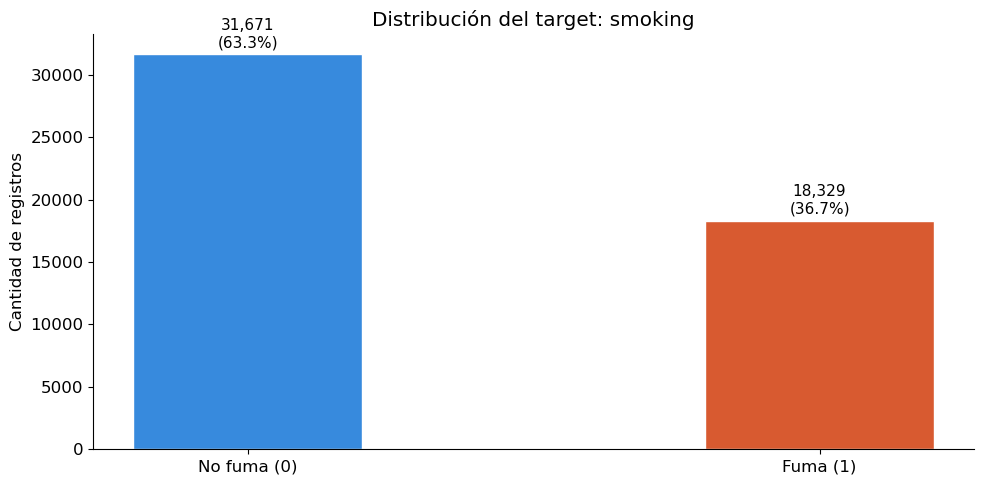

In [94]:
fig, ax = plt.subplots()
colores = ['#378ADD', '#D85A30']

ax.bar(conteo.index.astype(str), conteo.values, color=colores, width=0.4, edgecolor='white')
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    ax.text(i, v + conteo.max() * 0.01, f'{v:,}\n({p}%)', ha='center', va='bottom', fontsize=11)

ax.set_xticks([0, 1])
ax.set_xticklabels(['No fuma (0)', 'Fuma (1)'])
ax.set_ylabel('Cantidad de registros')
ax.set_title('Distribución del target: smoking')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Detección de outliers extremos
Usamos el método IQR. No los eliminamos aquí, solo los identificamos para tenerlos en cuenta en el EDA.

In [95]:
# Excluimos la columna id si existe
cols_analisis = [c for c in cols_numericas if c != 'id']

outlier_info = []
for col in cols_analisis:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    pct_out = round(n_outliers / len(df) * 100, 2)
    outlier_info.append({'columna': col, 'n_outliers': n_outliers, 'pct_%': pct_out})

outlier_df = pd.DataFrame(outlier_info).sort_values('n_outliers', ascending=False)
print(outlier_df[outlier_df['n_outliers'] > 0].to_string(index=False))

            columna  n_outliers  pct_%
      dental_caries       10656  21.31
                gtp        4330   8.66
                alt        3506   7.01
fasting_blood_sugar        2987   5.97
      urine_protein        2773   5.55
                ast        2698   5.40
       triglyceride        2013   4.03
      hearing_right        1310   2.62
       hearing_left        1283   2.57
         hemoglobin         966   1.93
                hdl         903   1.81
         relaxation         636   1.27
           systolic         619   1.24
                ldl         575   1.15
        cholesterol         543   1.09
           waist_cm         438   0.88
                age         274   0.55
          height_cm         233   0.47
          weight_kg         180   0.36
     eyesight_right          85   0.17
      eyesight_left          81   0.16
   serum_creatinine          21   0.04


## 9. Resumen del discovery y próximos pasos

In [96]:
print('RESUMEN DEL DISCOVERY')
print(f'  Filas         : {df.shape[0]:,}')
print(f'  Columnas      : {df.shape[1]}')
print(f'  Nulos         : {df.isnull().sum().sum()}')
print(f'  Duplicados    : {n_duplicados}')
print(f'  Numéricas     : {len(cols_numericas)}')
print(f'  Categóricas   : {len(cols_categoricas)}')
print(f'  Desbalance    : {ratio:.2f}x')
print()


RESUMEN DEL DISCOVERY
  Filas         : 50,000
  Columnas      : 27
  Nulos         : 0
  Duplicados    : 0
  Numéricas     : 24
  Categóricas   : 3
  Desbalance    : 1.73x



## 10. Guardar dataset limpio

In [97]:

output_path = os.path.join(BASE_DIR, 'data', 'processed', 'smoking_clean.csv')

df.to_csv(output_path, index=False)
print('Dataset guardado como smoking_clean.csv')

Dataset guardado como smoking_clean.csv
